# Solar interior composition (mass fractions)

Plot the mass fractions of hydrogen, <sup>4</sup>He, <sup>12</sup>C, <sup>14</sup>N, and <sup>16</sup>O fractions 
as a function of mass fraction  in the BP2004 standard non-rotating solar model. 

Data are from Bahcall and Pinsonneault 2004, astro-ph/0402114.

In [1]:
%matplotlib inline

import os, sys, math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# path handling

from pathlib import Path

# suppress nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Plot Format

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [2]:
# graphic aspect ratio = width/height

#aspect = 4.0/3.0 
aspect = 16.0/9.0

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 7
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'


## Data

Read in two columns from the BP2004 model file:
 * M/Msun = enclosed mass fraction in units of M<sub>sun</sub>
 * X = <sup>1</sup>H mass fraction
 * Y = <sup>4</sup>He mass fraction
 * C12 = <sup>12</sup>C mass fraction
 * N14 = <sup>14</sup>N mass fraction
 * O16 = <sup>16</sup>O mass fraction


In [3]:
# experimental data
dataDir = "BP2004"

dataFile = str(Path(dataDir) / "BP2004_Standard.txt")

data = pd.read_csv(dataFile,sep=r'\s+',comment='#')
massFrac = np.array(data['M/Msun']) 
X = np.array(data['X'])
Y = np.array(data['Y'])
c12 = np.array(data['C12'])
n14 = np.array(data['N14'])
o16 = np.array(data['O16'])

minM = 0 # M/Msun
maxM = 1.025
minX = 5.0e-6
maxX = 0.02

## Plot the composition in the sun

Plot is semi-log.  Plot as follows:
 * X - solid scarlet (#bb0000)
 * Y - solid green

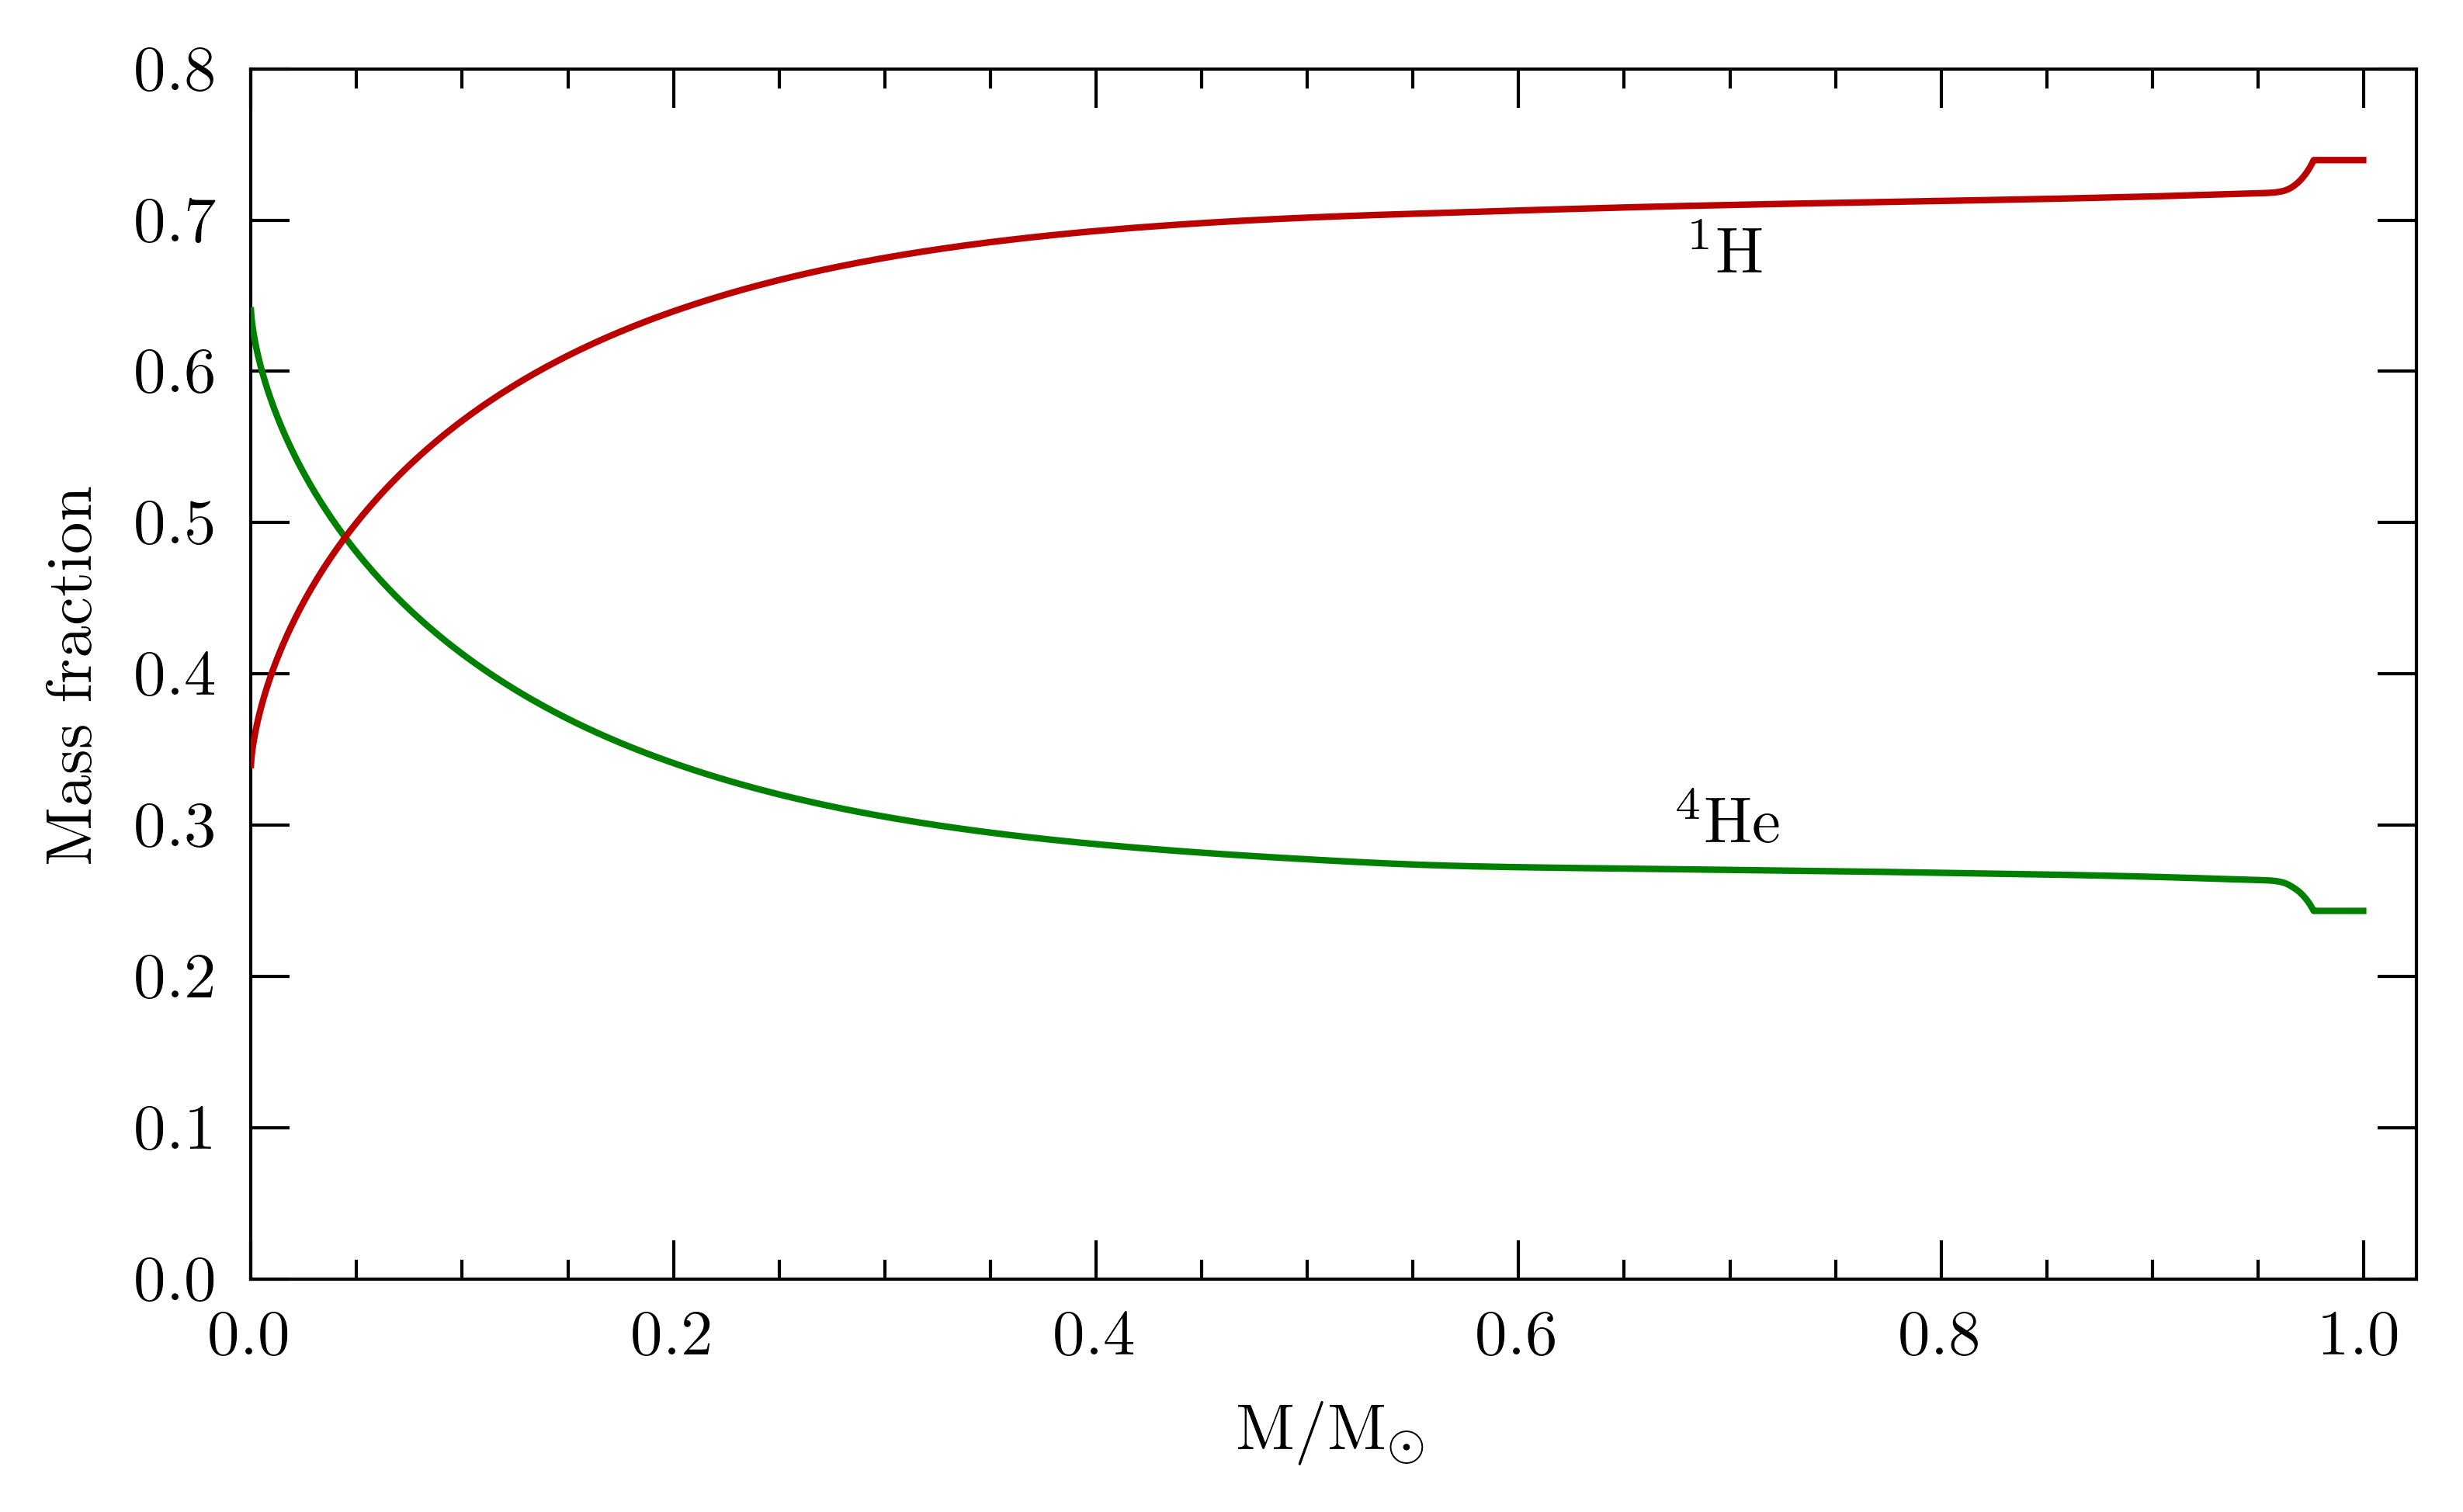

In [4]:
plotFile = "Solar_XYfraction.png"

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top=True,right=True)
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top=True,right=True)

ax.set_xlim(minM,maxM)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xlabel(r'M/M$_{\odot}$',fontsize=axisFontSize)

ax.set_ylim(0.0,0.8)
ax.set_ylabel(r'Mass fraction',fontsize=axisFontSize)
#ax.set_yticks([1e-5,1e-4,1e-3,1e-2])
#ax.set_yticklabels([r'10$^{-5}$','10$^{-4}$','0.001','0.01'])

ax.plot(massFrac,X,'-',color='#bb0000',lw=1,zorder=10)
ax.text(0.7,0.695,"$^{1}$H",va='top',ha='center',color="black",fontsize=axisFontSize)
ax.plot(massFrac,Y,'-',color='green',lw=1,zorder=9)
ax.text(0.7,0.28,"$^{4}$He",va='bottom',ha='center',color="black",fontsize=axisFontSize)

# Make the plot

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()

## Plot the CNO fraction

Plot is semi-log.  Plot as follows:
 * C12 - solid black
 * N14 - solid blue
 * O16 - solid green

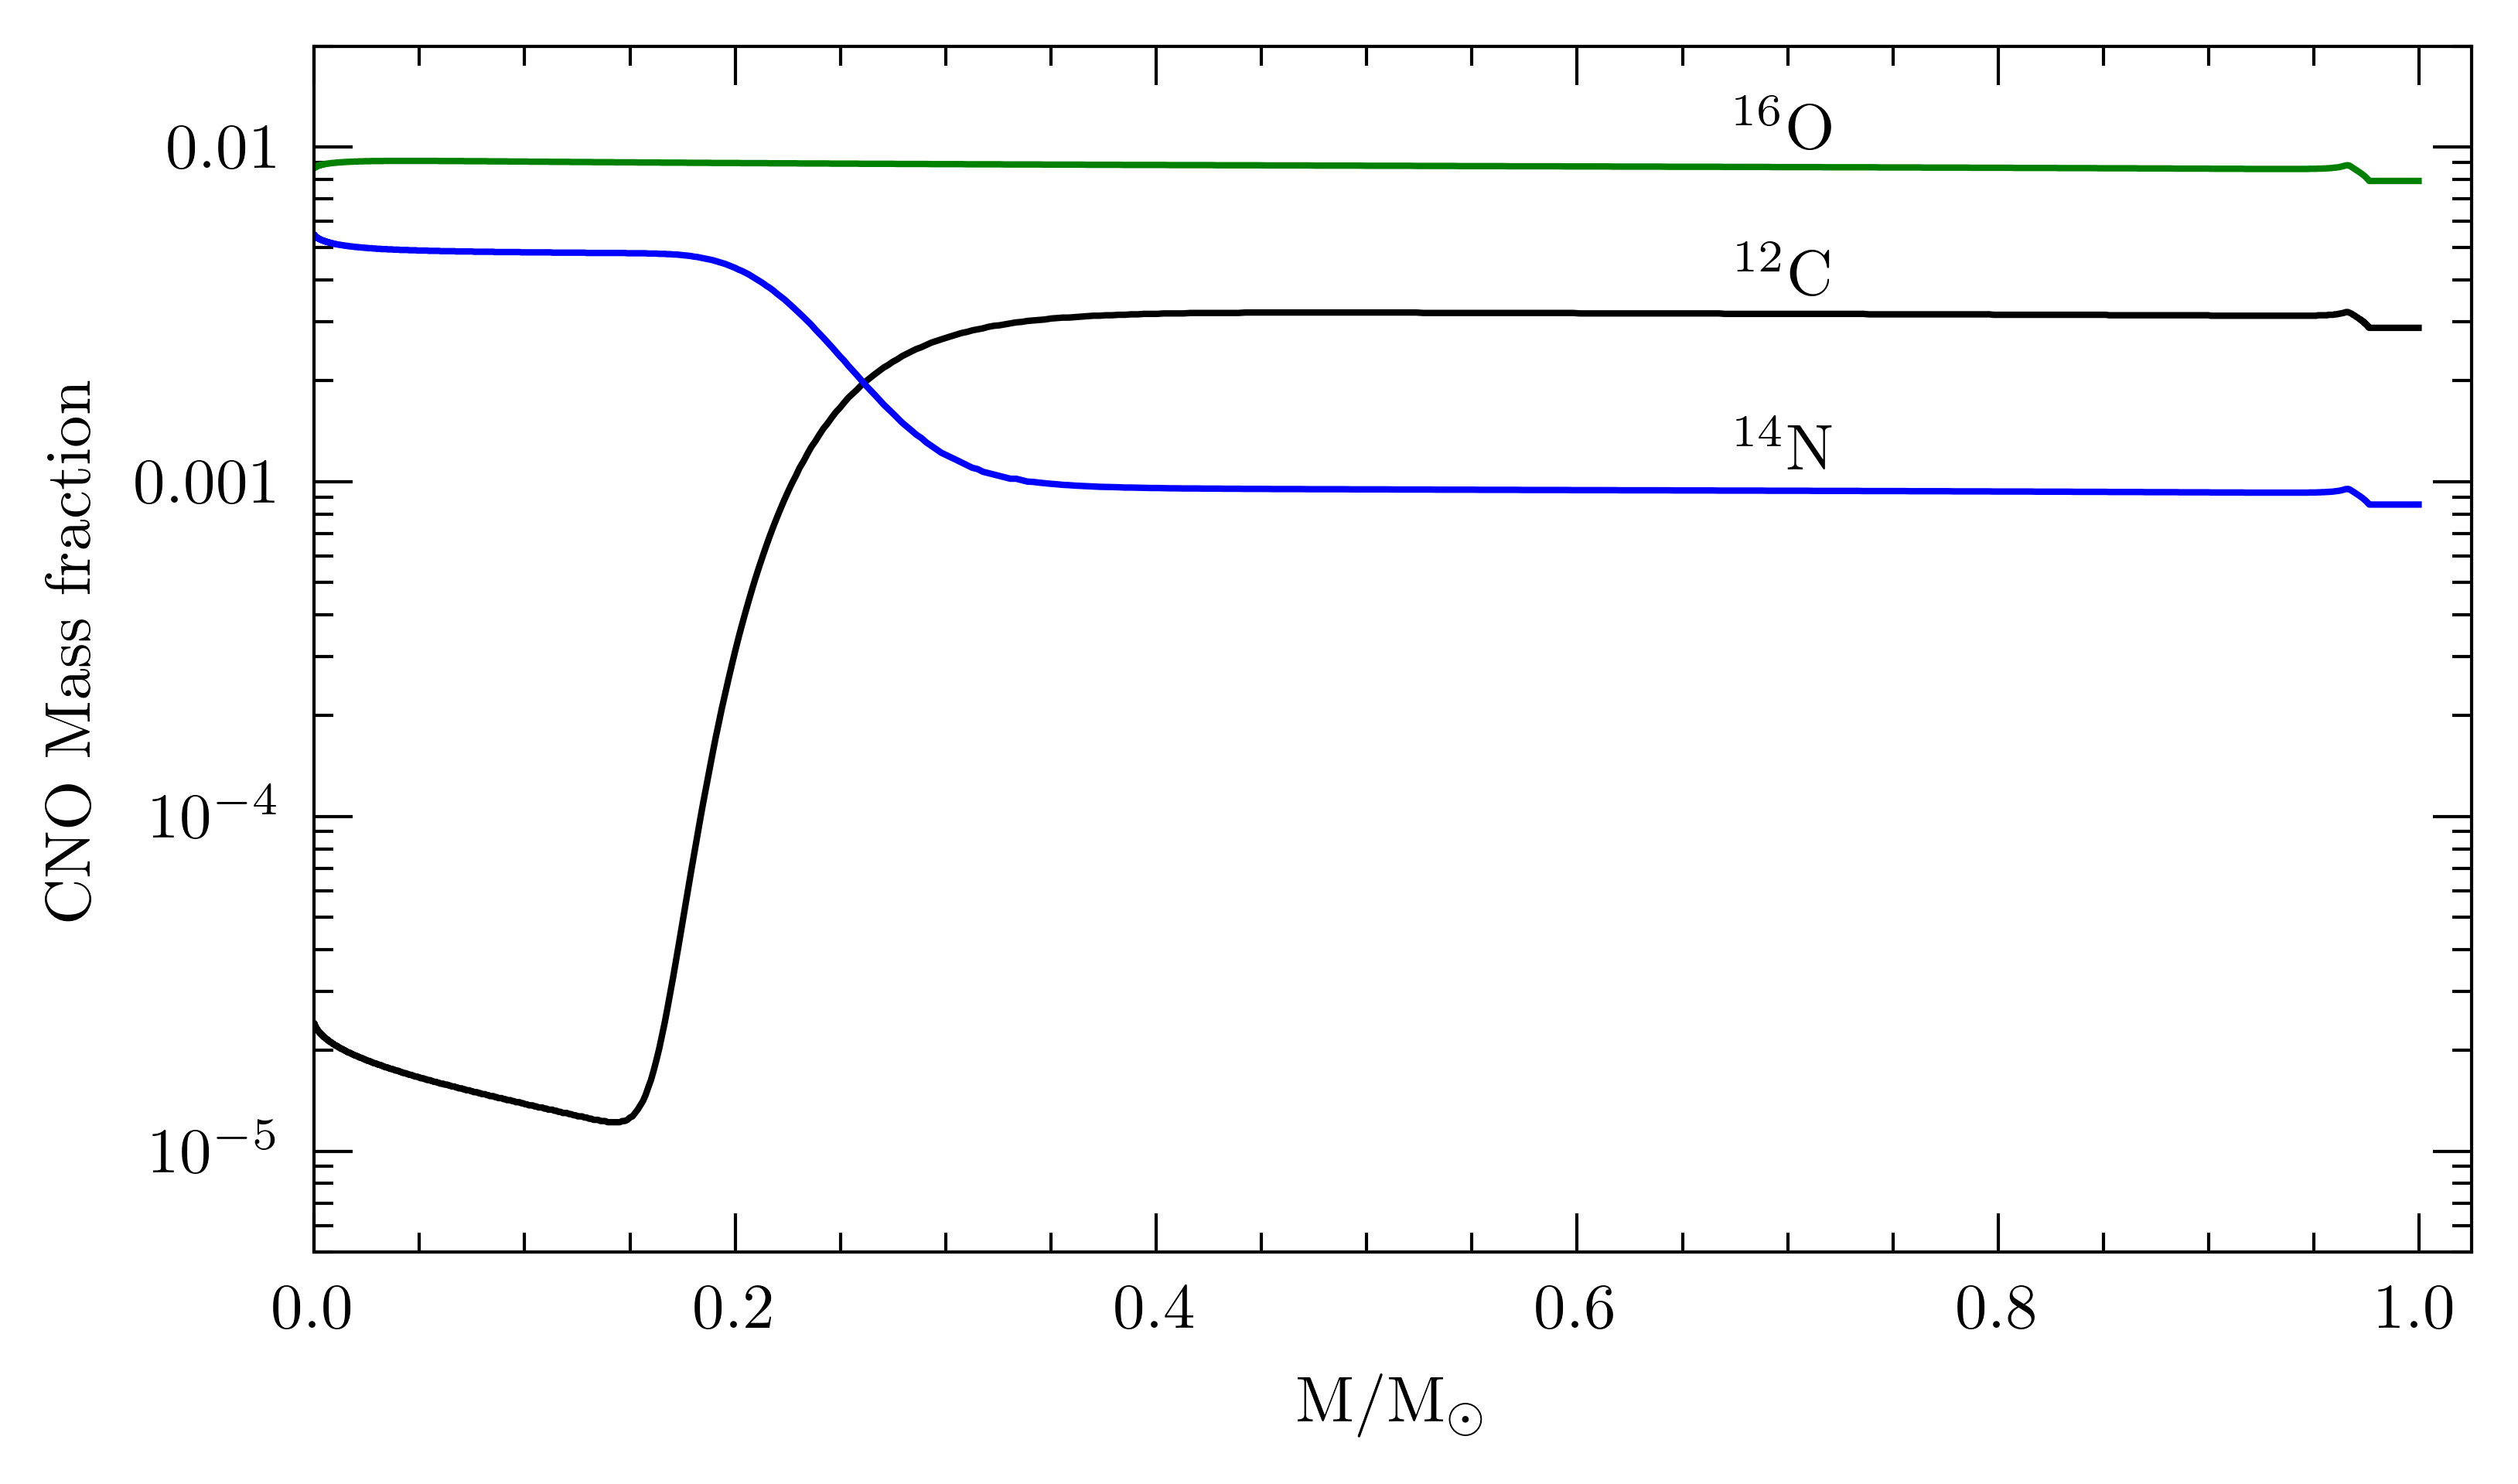

In [5]:
plotFile = 'Solar_CNOfraction.png'

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top=True,right=True)
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top=True,right=True)

ax.set_xlim(minM,maxM)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xlabel(r'M/M$_{\odot}$',fontsize=axisFontSize)

ax.set_ylim(minX,maxX)
ax.set_yscale('log')
ax.set_ylabel(r'CNO Mass fraction',fontsize=axisFontSize)
ax.set_yticks([1e-5,1e-4,1e-3,1e-2])
ax.set_yticklabels([r'10$^{-5}$','10$^{-4}$','0.001','0.01'])

ax.plot(massFrac,c12,'-',color='black',lw=1)
plt.text(0.7,0.0033,r'$^{12}$C',ha='center',va='bottom',fontsize=axisFontSize)

ax.plot(massFrac,n14,'-',color='blue',lw=1)
plt.text(0.7,0.001,r'$^{14}$N',ha='center',va='bottom',fontsize=axisFontSize)

ax.plot(massFrac,o16,'-',color='green',lw=1)
plt.text(0.7,0.009,r'$^{16}$O',ha='center',va='bottom',fontsize=axisFontSize)

# Make the plot

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()